In [2]:
import tensorflow as tf 
from tensorflow import keras 
import matplotlib.pyplot as plt 
%matplotlib inline 
import numpy as np

In [3]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [4]:
len(X_train)

60000

In [5]:
len(X_test)

10000

In [6]:
X_train.shape

(60000, 28, 28)

In [7]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

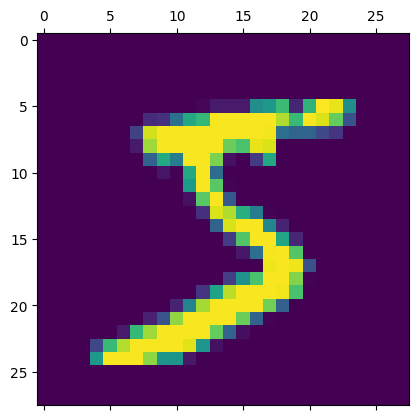

In [8]:
plt.matshow(X_train[0]) # matrix show

In [9]:
y_train[0]

np.uint8(5)

In [10]:
y_train[:5]

array([5, 0, 4, 1, 9], dtype=uint8)

In [11]:
X_train = X_train/255 # !important 
X_test = X_test/255

In [12]:
X_train_flattened = X_train.reshape(X_train.shape[0], 28 * 28 )
X_test_flattened = X_test.reshape(X_test.shape[0], 28 * 28 )

In [13]:
X_train_flattened.shape

(60000, 784)

In [14]:
X_train_flattened[0] # from 2d to 1d

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [15]:
model = keras.Sequential([ # stack of neural networks 
    # output is 10 (maybe is the input of the next layer), intput node count = 784
    keras.layers.Dense(10, input_shape=(784, ), activation='sigmoid')
])

model.compile(optimizer='adam', 
              # sparse: because the output variable (y_label) is actually an integer number
              # if it is onehot encoded array => use categorical_crossentropy
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
)

model.fit(X_train_flattened, y_train, epochs = 5)

c:\Users\HuyenDT\source\repos\sttproject\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8783 - loss: 0.4675
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9148 - loss: 0.3035
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9211 - loss: 0.2832
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9229 - loss: 0.2732
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9259 - loss: 0.2667


In [16]:
model.evaluate(X_test_flattened, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9248 - loss: 0.2715


[0.2714686095714569, 0.9247999787330627]

In [17]:
y_predicted = model.predict(X_test_flattened)
y_predicted[0] # probabilities for 10 classes

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([6.2041193e-02, 4.1616823e-07, 5.1488012e-02, 9.7008753e-01,
       3.1565498e-03, 1.3146436e-01, 1.7407026e-06, 9.9989736e-01,
       1.4658080e-01, 6.8173414e-01], dtype=float32)

In [18]:
np.argmax(y_predicted[0])

np.int64(7)

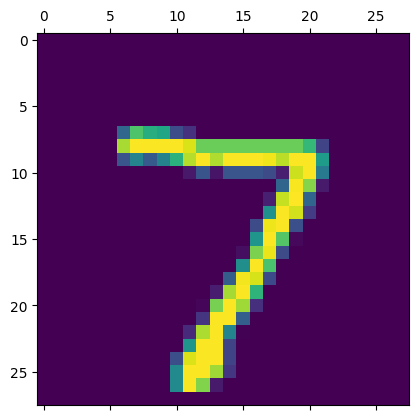

In [19]:
plt.matshow(X_test[0])

In [20]:
y_predicted_labels = [np.argmax(i) for i in y_predicted]


In [21]:
y_predicted_labels[:5]

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4)]

In [22]:
y_test[:5]

array([7, 2, 1, 0, 4], dtype=uint8)

In [23]:
cm = tf.math.confusion_matrix(y_test, y_predicted_labels)
cm 

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 968,    0,    0,    2,    0,    4,    2,    2,    2,    0],
       [   0, 1109,    3,    2,    0,    1,    4,    2,   14,    0],
       [  13,    9,  913,   16,    9,    2,   10,   14,   44,    2],
       [   5,    0,   19,  912,    0,   22,    2,   13,   29,    8],
       [   2,    1,    4,    1,  918,    0,    8,    5,   10,   33],
       [  13,    3,    1,   32,   11,  761,   13,    8,   43,    7],
       [  17,    3,    6,    1,    8,   10,  908,    2,    3,    0],
       [   2,    5,   23,    2,    5,    0,    0,  967,    2,   22],
       [  10,    7,    6,   14,    9,   20,    7,   14,  882,    5],
       [  12,    6,    1,    9,   29,    4,    0,   31,    7,  910]],
      dtype=int32)>

Text(95.72222222222221, 0.5, 'Truth')

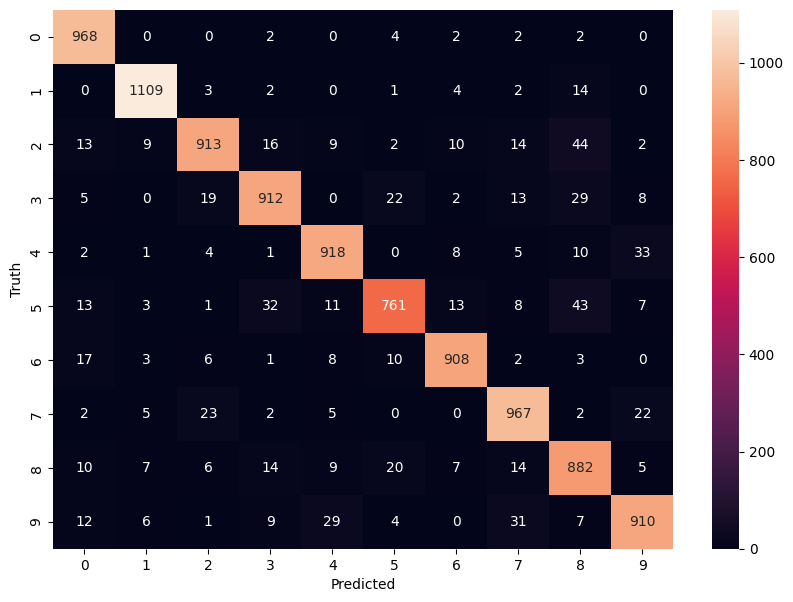

In [24]:
import seaborn as sns

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d') # anything that is not in the diagonal is the error
plt.xlabel("Predicted")
plt.ylabel("Truth")

In [25]:
model = keras.Sequential([
    keras.layers.Dense(100, input_shape=(784, ), activation='relu'),
    keras.layers.Dense(10, activation='sigmoid') # adding more hidden layers tends to imporve the performance
])

model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
)

model.fit(X_train_flattened, y_train, epochs = 5)

c:\Users\HuyenDT\source\repos\sttproject\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9209 - loss: 0.2787
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9621 - loss: 0.1283
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9735 - loss: 0.0886
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9807 - loss: 0.0662
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9835 - loss: 0.0526


In [26]:
model.evaluate(X_test_flattened, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9742 - loss: 0.0861


[0.08614902198314667, 0.9742000102996826]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 845us/step


Text(95.72222222222221, 0.5, 'Truth')

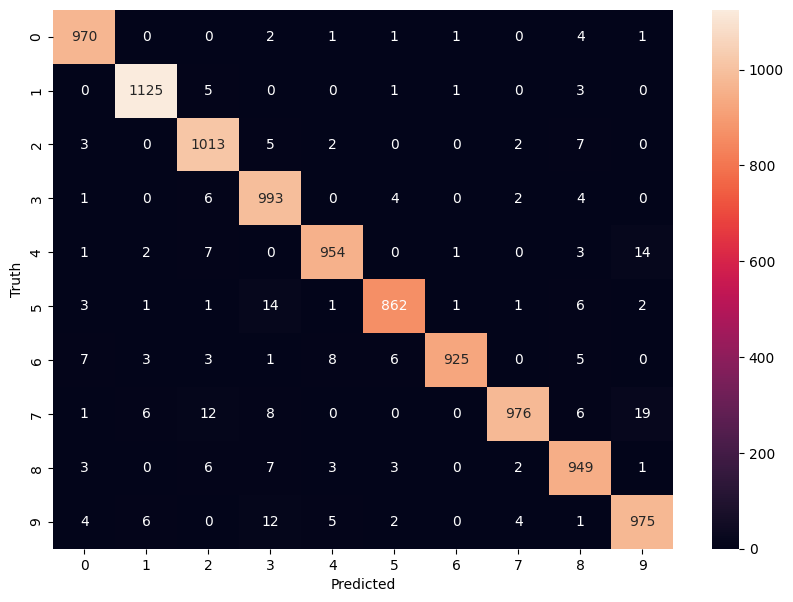

In [27]:
y_predicted = model.predict(X_test_flattened)
y_predicted_labels = [np.argmax(i) for i in y_predicted]
cm = tf.math.confusion_matrix(y_test, y_predicted_labels)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d') # anything that is not in the diagonal is the error
plt.xlabel("Predicted")
plt.ylabel("Truth")

In [28]:
# if don't want to flatten input before training => add Flatten layer
# add dropout layer (usually after every other layers => to reduce overfitting)
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(100, activation='relu'),  # in case, don't know what activation function to use, go with relu
    keras.layers.Dense(10, activation='sigmoid') # adding more hidden layers tends to imporve the performance
])

model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', # learning_rate usually = 0.01, w1 = w1 - learning rate.deriative(y(x1))
    metrics=['accuracy']
)

model.fit(X_train, y_train, epochs = 5)

Epoch 1/5


c:\Users\HuyenDT\source\repos\sttproject\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9249 - loss: 0.2659
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9645 - loss: 0.1202
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9751 - loss: 0.0834
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9812 - loss: 0.0643
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9851 - loss: 0.0500


In [29]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9744 - loss: 0.0835


[0.08351891487836838, 0.974399983882904]

In [30]:
y_predicted = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 890us/step


### CNN

In [33]:
X_train.shape


(60000, 28, 28)

In [35]:
cnn = keras.Sequential([
    #cnn
    keras.layers.Conv2D(input_shape=(28,28,1), filters =32, kernel_size=(3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    #dense
    keras.layers.Flatten(),
    keras.layers.Dense(100, activation='relu'),  # in case, don't know what activation function to use, go with relu
    keras.layers.Dense(10, activation='softmax') # adding more hidden layers tends to imporve the performance
])

cnn.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', # learning_rate usually = 0.01, w1 = w1 - learning rate.deriative(y(x1))
    metrics=['accuracy']
)

cnn.fit(X_train, y_train, epochs = 5)

c:\Users\HuyenDT\source\repos\sttproject\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9555 - loss: 0.1520
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9842 - loss: 0.0517
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9900 - loss: 0.0319
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9934 - loss: 0.0216
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9952 - loss: 0.0147


In [36]:
cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9876 - loss: 0.0441


[0.04408778250217438, 0.9876000285148621]